In [226]:
import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates
from pandas.plotting import scatter_matrix
import seaborn as sns
from xgboost import XGBRegressor

from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error

from statsmodels.graphics.tsaplots import plot_acf

In [228]:
# Load Train dataset.
TRAIN_LOAD_LOCATION = '../data/raw/train.xlsx'

df = pd.read_excel(TRAIN_LOAD_LOCATION)

In [229]:
def df_transformer(df):

    YEARS_DICT = {1:2020, 2:2021, 3:2022}

    TEMP_COLS = [f"Site-{i + 1} Temp" for i in range(5)]
    GHI_COLS = [f"Site-{i + 1} GHI" for i in range(5)]

    # Holidays considered: New_Years_Day, Independence_Day, Thanksgiving_Day, Day_After_Thanksgiving, Christmas_Eve, Christmas_Day, New_Years_Eve
    list_of_notable_days = ["2020-01-01", "2020-07-04", "2020-11-26", "2020-11-27", "2020-12-24", "2020-12-25", "2020-12-31", 
                        "2021-01-01", "2021-07-04", "2021-11-25", "2021-11-26", "2021-12-24", "2021-12-25", "2021-12-31",
                        "2023-01-01", "2023-07-04", "2023-11-23", "2023-11-24", "2023-12-24", "2023-12-25", "2023-12-31"]

    base_t = 60

    notable_days = pd.to_datetime(list_of_notable_days)
    
    df_transformed = df.copy()
    
    # Transform temperature readings to Farenheit.
    df_transformed[TEMP_COLS] = df_transformed[TEMP_COLS].apply(lambda x: x * 9/5 + 32)
    
    # Average the temperature and GHI measurements across all sites, to explore temperature effects simply.
    df_transformed["avg_region_temp"] = df_transformed[TEMP_COLS].mean(axis=1)
    df_transformed["avg_region_ghi"] = df_transformed[GHI_COLS].mean(axis=1)
    
    # Create timestamps.
    df_transformed['Year'] = df_transformed['Year'].map(YEARS_DICT)
    df_transformed['Hour'] = df_transformed['Hour'] - 1
    df_transformed['timestamp'] = pd.to_datetime(df_transformed[['Year', 'Month', 'Day', 'Hour']])

    df_transformed["Hour_sin"] = np.sin(2*np.pi*df_transformed["Hour"]/24)
    df_transformed["Hour_cos"] = np.cos(2*np.pi*df_transformed["Hour"]/24)
    
    df_transformed["Month_sin"] = np.sin(2*np.pi*df_transformed["Month"]/24)
    df_transformed["Month_cos"] = np.cos(2*np.pi*df_transformed["Month"]/24)

    df_transformed["CDH"] = (df_transformed["avg_region_temp"] - base_t).clip(lower=0)
    df_transformed["HDH"] = (base_t - df_transformed["avg_region_temp"]).clip(lower=0)

    # Average of the temperature for the last 3, 6, and 24 hours.
    df_transformed["temp_3h"] = df_transformed["avg_region_temp"].rolling(3).mean()
    df_transformed["temp_6h"] = df_transformed["avg_region_temp"].rolling(6).mean()
    df_transformed["temp_24h"] = df_transformed["avg_region_temp"].rolling(24).mean()
    
    # Aggregate of the Cooling Degree Hours for the last 3, 6, and 24 hours.
    df_transformed["CDH_3h"] = df_transformed["CDH"].rolling(3).sum()
    df_transformed["CDH_6h"] = df_transformed["CDH"].rolling(6).sum()
    df_transformed["CDH_24h"] = df_transformed["CDH"].rolling(24).sum()
    
    # Aggregate of the Heating Degree Hours for the last 3, 6, and 24 hours.
    df_transformed["HDH_3h"] = df_transformed["HDH"].rolling(3).sum()
    df_transformed["HDH_6h"] = df_transformed["HDH"].rolling(6).sum()
    df_transformed["HDH_24h"] = df_transformed["HDH"].rolling(24).sum()

    # Ensure chronological ordering.
    df_transformed = df_transformed.sort_values("timestamp")

    df_transformed["Load_lag_1h"] = df_transformed["Load"].shift(1)
    df_transformed["Load_lag_2h"] = df_transformed["Load"].shift(2)
    df_transformed["Load_lag_3h"] = df_transformed["Load"].shift(3)
    df_transformed["Load_lag_6h"] = df_transformed["Load"].shift(6)
    df_transformed["Load_lag_12h"] = df_transformed["Load"].shift(12)
    df_transformed["Load_lag_24h"] = df_transformed["Load"].shift(24)
    df_transformed["Load_lag_48h"] = df_transformed["Load"].shift(48)
    df_transformed["Load_lag_168h"] = df_transformed["Load"].shift(168)

    df_transformed = df_transformed.dropna()

    # Add feature indicating weekend.
    df_transformed['is_weekend'] = (df_transformed['timestamp'].dt.weekday >= 5).astype(int)

    # Add feature indicating notable days.
    df_transformed['is_notable_day'] = (df_transformed['timestamp'].dt.normalize().isin(notable_days)).astype(int)

    # Rearrange columns

    cols = list(df_transformed.columns)
    cols.remove("timestamp")
    df_transformed = df_transformed[["timestamp"] + cols]

    return df_transformed

In [230]:
df = df_transformer(df)

In [231]:
df.head()

,timestamp,Year,Month,Day,Hour,Load,Site-1 Temp,Site-2 Temp,Site-3 Temp,Site-4 Temp,...,Load_lag_1h,Load_lag_2h,Load_lag_3h,Load_lag_6h,Load_lag_12h,Load_lag_24h,Load_lag_48h,Load_lag_168h,is_weekend,is_notable_day
168,2020-01-08 00:00:00,2020,1,8,0,1956,46.22,48.02,48.02,48.56,...,2018.0,2176.0,2386.0,2708.0,1885.0,1902.0,1882.0,1997.0,0,0
169,2020-01-08 01:00:00,2020,1,8,1,1925,46.22,47.12,46.76,47.48,...,1956.0,2018.0,2176.0,2634.0,1952.0,1839.0,1824.0,1921.0,0,0
170,2020-01-08 02:00:00,2020,1,8,2,1899,48.02,49.64,45.32,47.66,...,1925.0,1956.0,2018.0,2529.0,2079.0,1801.0,1794.0,1861.0,0,0
171,2020-01-08 03:00:00,2020,1,8,3,1901,52.88,52.16,44.96,47.84,...,1899.0,1925.0,1956.0,2386.0,2244.0,1811.0,1810.0,1833.0,0,0
172,2020-01-08 04:00:00,2020,1,8,4,1969,51.44,52.88,44.24,46.40,...,1901.0,1899.0,1925.0,2176.0,2485.0,1900.0,1912.0,1847.0,0,0


In [232]:
splits_df_loc = "../data/splits/split_bounds.csv"
splits_df = pd.read_csv(splits_df_loc)

def xgbr_rmse_on_features(df, xgbr_depth, xgbr_estimators):

    rmse_list = []

    for i in range(1, 6):
        split = f"split_{i}"
    
        row = splits_df[splits_df["split"] == split].iloc[0]
        train_start_date = row["train_start_date"]
        train_end_date = row["train_end_date"]
        val_start_date = row["val_start_date"]
        val_end_date = row["val_end_date"]
    
        train_mask = (df["timestamp"] >= train_start_date) & (df["timestamp"] < train_end_date)
        val_mask = (df["timestamp"] >= val_start_date) & (df["timestamp"] < val_end_date)
        
        train_split = df[train_mask].drop(columns=["timestamp"])
        val_split = df[val_mask].drop(columns=["timestamp"])
    
        X_train = train_split.drop(columns=["Load"])
        y_train = train_split["Load"]
    
        X_val = val_split.drop(columns=["Load"])
        y_val = val_split["Load"]
    
        model = XGBRegressor(objective='reg:squarederror', n_estimators = xgbr_estimators, learning_rate=0.1, max_depth = xgbr_depth, subsample=0.8)

        model.fit(X_train, y_train)
    
        y_pred = model.predict(X_val)
        rmse = root_mean_squared_error(y_val, y_pred)
    
        rmse_list.append(rmse)
    print("RMSEs: ", rmse_list)
    print(f"Average RMSE across splits: {np.mean(rmse_list):.2f} ± {np.std(rmse_list):.2f}\n")
    return np.mean(rmse_list), np.std(rmse_list)

In [238]:
depths = [i for i in range(3, 7)]
grid_search = {depth:([], []) for depth in depths}
estimators = [i for i in range(50, 1050, 50)]

for depth in depths:
    
    for n_estimators in estimators:
        
        print(f"depth:{depth}, n_estimators:{n_estimators}")
        xgbr_mean, xgbr_std = xgbr_rmse_on_features(df = df, xgbr_depth = depth, xgbr_estimators = n_estimators)
        grid_search[depth][0].append(xgbr_mean)
        grid_search[depth][1].append(xgbr_std)

depth:3, n_estimators:50
RMSEs:  [64.36654376340522, 69.35952952506202, 61.21958343242384, 70.87378895522305, 78.95816768132407]
Average RMSE across splits: 68.96 ± 6.08

depth:3, n_estimators:100
RMSEs:  [57.77373674205528, 56.75331501598029, 53.088049206602015, 64.9399071528897, 71.56101721065922]
Average RMSE across splits: 60.82 ± 6.60

depth:3, n_estimators:150
RMSEs:  [56.272757101070034, 52.54026767055735, 49.61957436017524, 61.91866798080851, 67.78296990508271]
Average RMSE across splits: 57.63 ± 6.53

depth:3, n_estimators:200
RMSEs:  [55.00944014250166, 50.42038075698473, 48.307783302465054, 59.57938296646599, 65.50610322893408]
Average RMSE across splits: 55.76 ± 6.23

depth:3, n_estimators:250
RMSEs:  [55.03099432129159, 49.152604228506746, 46.891372748565686, 57.102151759510186, 63.78584805960224]
Average RMSE across splits: 54.39 ± 6.00

depth:3, n_estimators:300
RMSEs:  [54.51931787449175, 48.189794934610255, 46.25005644197282, 56.24278557800526, 62.554612564165595]
Aver

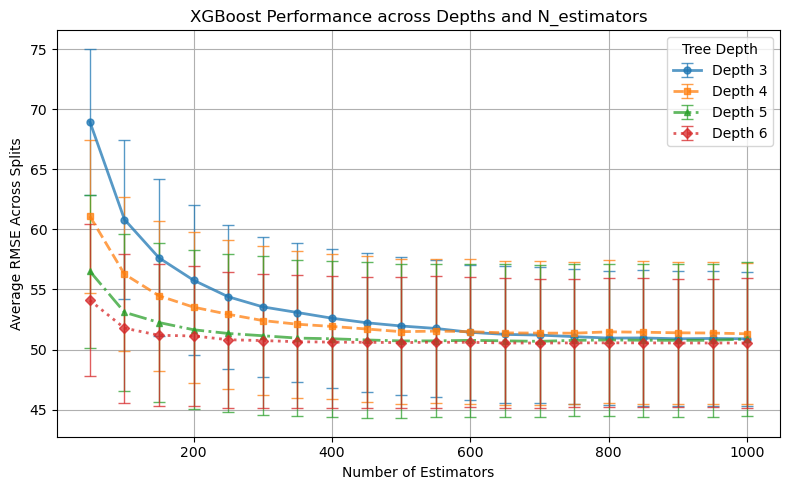

In [240]:
fig, ax = plt.subplots(1, 1, figsize=(8,5))

ax.set_title("XGBoost Performance across Depths and N_estimators")

markers = ['o', 's', '^', 'D', 'v', 'P']
linestyles = ['-', '--', '-.', ':', '-', '--']

for i, depth in enumerate(depths):
    ax.errorbar(
        estimators,
        grid_search[depth][0],
        yerr=grid_search[depth][1],
        label=f"Depth {depth}",
        marker=markers[i % len(markers)],
        linestyle=linestyles[i % len(linestyles)],
        linewidth=2,
        markersize=5,
        capsize=4,
        capthick=1,
        elinewidth=1,
        alpha=0.75
    )

ax.set_xlabel("Number of Estimators")
ax.set_ylabel("Average RMSE Across Splits")
ax.legend(title="Tree Depth")
ax.grid(True)
plt.tight_layout()

Training XGBoost on the full feature set across a range of depths and number of estimators shows that performance plateaus around an RMSE of 50.5. To select a final model for evaluation on the test set, I choose the simplest model—i.e., the model with the lowest depth and fewest estimators—whose RMSE is within 0.5 of the lowest observed RMSE. This ensures near-optimal performance while avoiding unnecessary complexity and potential overfitting.

In [243]:
candidates = [
    (depth, n, mean, std)
    for i, depth in enumerate(depths)
    for j, n in enumerate(estimators)
    for mean, std in [(grid_search[depth][0][j], grid_search[depth][1][j])]
]

# Convert to DataFrame
df_candidates = pd.DataFrame(candidates, columns=['depth', 'n_estimators', 'mean_rmse', 'std_rmse'])

# Define plateau threshold
best_idx = df_candidates['mean_rmse'].idxmin()
best_mean = df_candidates.loc[best_idx, 'mean_rmse']
best_std = df_candidates.loc[best_idx, 'std_rmse']
plateau_threshold = best_mean + best_std


# Filter plateau models
df_plateau = df_candidates[df_candidates['mean_rmse'] <= plateau_threshold]

# Pick simplest model: lowest depth and fewest estimators
best_model = df_plateau.sort_values(['depth', 'n_estimators']).iloc[0]
print(best_model)


depth             3.000000
n_estimators    200.000000
mean_rmse        55.764618
std_rmse          6.231926
Name: 3, dtype: float64


In [249]:
splits_df_loc = "../data/splits/split_bounds.csv"
splits_df = pd.read_csv(splits_df_loc)

def linear_xgbr_rmse_on_features(df, features_to_train_lin, xgbr_depth, xgbr_estimators):

    #print("Now training on: ", features_to_train_lin)

    rmse_list = []
    df = df.sort_values(by=["timestamp"])

    for i in range(1, 6):
        split = f"split_{i}"
    
        row = splits_df[splits_df["split"] == split].iloc[0]
        train_start_date = row["train_start_date"]
        train_end_date = row["train_end_date"]
        val_start_date = row["val_start_date"]
        val_end_date = row["val_end_date"]
    
        train_mask = (df["timestamp"] >= train_start_date) & (df["timestamp"] < train_end_date)
        val_mask = (df["timestamp"] >= val_start_date) & (df["timestamp"] < val_end_date)
        
        train_split = df[train_mask].drop(columns=["timestamp", "Load"])
        val_split = df[val_mask].drop(columns=["timestamp", "Load"])
    
        X_train = train_split[features_to_train_lin]
        y_train = df[train_mask]["Load"]
    
        X_val = val_split[features_to_train_lin]
        y_val = df[val_mask]["Load"]

        n_train_samples = len(X_train)
        initial_len = int(0.6 * n_train_samples)
        step_size = 24

        oos_residuals = np.full(n_train_samples, np.nan)

        for start in range(initial_len, n_train_samples, step_size):
            end = min(start + step_size, n_train_samples)

            wf_lin = LinearRegression()
            wf_lin.fit(X_train.iloc[:start], y_train.iloc[:start])
        
            preds = wf_lin.predict(X_train.iloc[start:end])

            oos_residuals[start:end] = y_train.iloc[start:end] - preds

        mask = ~np.isnan(oos_residuals)

        xgbr = XGBRegressor(objective='reg:squarederror', n_estimators = xgbr_estimators, learning_rate=0.05, max_depth = xgbr_depth, subsample=0.8, random_state=12)
        xgbr.fit(train_split.iloc[mask], oos_residuals[mask])

        model = LinearRegression()
        model.fit(X_train, y_train)
    
        y_lin_pred = model.predict(X_val)
        y_xgbr_pred = xgbr.predict(val_split)
        rmse = root_mean_squared_error(y_val, y_lin_pred + y_xgbr_pred)
    
        rmse_list.append(rmse)
    print("RMSEs: ", rmse_list)
    print(f"Average RMSE across splits: {np.mean(rmse_list):.2f} ± {np.std(rmse_list):.2f}\n")
    return np.mean(rmse_list), np.std(rmse_list)

In [257]:
depths = [i for i in range(3, 7)]
lin_xgb_grid_search = {depth:([], []) for depth in depths}
estimators = [i for i in range(50, 1050, 50)]

for depth in depths:
    
    for n_estimators in estimators:
        
        print(f"depth:{depth}, estimators:{n_estimators}")
        lin_xgbr_mean, lin_xgbr_std = linear_xgbr_rmse_on_features(df = df, 
                                    features_to_train_lin = ["Hour_sin", "Hour_cos", "Month", "Day", "temp_6h", "avg_region_ghi", "is_weekend", "is_notable_day", "CDH", "HDH", "Load_lag_1h", "Load_lag_2h", "Load_lag_3h", "Load_lag_24h"],
                                    xgbr_depth = depth, xgbr_estimators = n_estimators)
        lin_xgb_grid_search[depth][0].append(lin_xgbr_mean)
        lin_xgb_grid_search[depth][1].append(lin_xgbr_std)


depth:3, estimators:50
RMSEs:  [55.01857316351681, 57.9758124379494, 50.47442576359052, 55.17022662752877, 61.61718565197405]
Average RMSE across splits: 56.05 ± 3.68

depth:3, estimators:100
RMSEs:  [55.516349835763315, 57.01709961367266, 49.162696389575245, 55.472707407073656, 60.366018961543]
Average RMSE across splits: 55.51 ± 3.64

depth:3, estimators:150
RMSEs:  [55.510027709933716, 57.064975366977826, 48.571529860248084, 54.65729891147257, 59.884679168730294]
Average RMSE across splits: 55.14 ± 3.73

depth:3, estimators:200
RMSEs:  [56.72752240579033, 58.207104186602194, 48.129600931280464, 54.23909360384676, 59.54777415025558]
Average RMSE across splits: 55.37 ± 4.03

depth:3, estimators:250
RMSEs:  [57.6907724362835, 57.99467863717022, 47.98734712069819, 53.936903930663576, 59.17144712432468]
Average RMSE across splits: 55.36 ± 4.08

depth:3, estimators:300
RMSEs:  [58.26857424550409, 57.68779478024162, 47.81199272981319, 54.026749901418, 58.939834967314845]
Average RMSE acros

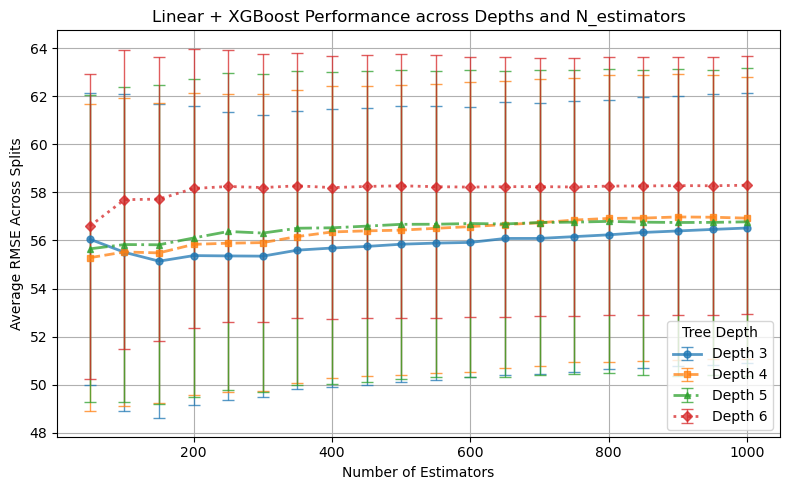

In [259]:
fig, ax = plt.subplots(1, 1, figsize=(8,5))

ax.set_title("Linear + XGBoost Performance across Depths and N_estimators")

markers = ['o', 's', '^', 'D', 'v', 'P']
linestyles = ['-', '--', '-.', ':', '-', '--']

for i, depth in enumerate(depths):
    ax.errorbar(
        estimators,
        lin_xgb_grid_search[depth][0],
        yerr=grid_search[depth][1],
        label=f"Depth {depth}",
        marker=markers[i % len(markers)],
        linestyle=linestyles[i % len(linestyles)],
        linewidth=2,
        markersize=5,
        capsize=4,
        capthick=1,
        elinewidth=1,
        alpha=0.75
    )

ax.set_xlabel("Number of Estimators")
ax.set_ylabel("Average RMSE Across Splits")
ax.legend(title="Tree Depth")
ax.grid(True)
plt.tight_layout()

In [261]:
candidates = [
    (depth, n, mean, std)
    for i, depth in enumerate(depths)
    for j, n in enumerate(estimators)
    for mean, std in [(lin_xgb_grid_search[depth][0][j], lin_xgb_grid_search[depth][1][j])]
]

# Convert to DataFrame
df_candidates = pd.DataFrame(candidates, columns=['depth', 'n_estimators', 'mean_rmse', 'std_rmse'])

# Define plateau threshold
best_idx = df_candidates['mean_rmse'].idxmin()
best_mean = df_candidates.loc[best_idx, 'mean_rmse']
best_std = df_candidates.loc[best_idx, 'std_rmse']
plateau_threshold = best_mean + best_std

# Filter plateau models
df_plateau = df_candidates[df_candidates['mean_rmse'] <= plateau_threshold]

# Pick simplest model: lowest depth and fewest estimators
best_model = df_plateau.sort_values(['depth', 'n_estimators']).iloc[0]
print(best_model)


depth            3.000000
n_estimators    50.000000
mean_rmse       56.051245
std_rmse         3.677694
Name: 0, dtype: float64
